# BMA — Kaggle Setup, Corpus EDA, Runtime, and Held-out Labels (Phases 0–3)

This notebook is ready to run in Kaggle with **Run All**. It clones or updates the public repository, installs the local `doc_agent` package, verifies the environment and GPU, discovers attached PDF inputs, loads the project configuration, and writes a smoke-test artifact.

Before running, attach the two source PDFs as a **private Kaggle dataset**. The notebook discovers PDFs anywhere under `/kaggle/input`, so the Kaggle dataset slug does not need to be hard-coded.

In [1]:
# Configuration — normally no edits are required.
from pathlib import Path

REPO_URL = "https://github.com/FAHIM-ISHTIAK/doc-agent-20.git"
REPO_BRANCH = "fahim"  # Phase branch; change to main after the PR is merged.
REPO_DIR = Path("/kaggle/working/doc-agent-20")
KAGGLE_INPUT = Path("/kaggle/input")
ARTIFACT_DIR = Path("/kaggle/working/artifacts")

print("Repository:", REPO_URL)
print("Branch:", REPO_BRANCH)
print("Working copy:", REPO_DIR)
print("Kaggle inputs:", KAGGLE_INPUT)


Repository: https://github.com/FAHIM-ISHTIAK/doc-agent-20.git
Branch: fahim
Working copy: /kaggle/working/doc-agent-20
Kaggle inputs: /kaggle/input


## 1. Inspect the Kaggle runtime

In [2]:
import os
import platform
import subprocess
import sys

print("Python:", sys.version.replace("\n", " "))
print("Platform:", platform.platform())
print("Current directory:", Path.cwd())

try:
    import torch
    print("PyTorch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    print("CUDA version:", torch.version.cuda)
    if torch.cuda.is_available():
        print("GPU count:", torch.cuda.device_count())
        for gpu_index in range(torch.cuda.device_count()):
            print(f"GPU {gpu_index}:", torch.cuda.get_device_name(gpu_index))
    else:
        print("WARNING: No GPU detected. In Kaggle, open Settings -> Accelerator and select a GPU.")
except Exception as exc:
    print("PyTorch inspection failed:", repr(exc))


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.12.90+-x86_64-with-glibc2.35
Current directory: /kaggle/working
PyTorch: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


## 2. Clone or update the repository

The cell is safe to run again. If a clean Git checkout already exists, it updates `main` with a fast-forward pull. It does not delete or overwrite an unrelated directory.

In [3]:
def run_command(command, cwd=None):
    print("$", " ".join(map(str, command)))
    completed = subprocess.run(
        [str(part) for part in command],
        cwd=str(cwd) if cwd else None,
        check=True,
        text=True,
        capture_output=True,
    )
    if completed.stdout.strip():
        print(completed.stdout.strip())
    if completed.stderr.strip():
        print(completed.stderr.strip())
    return completed

if REPO_DIR.exists():
    if not (REPO_DIR / ".git").is_dir():
        raise RuntimeError(f"{REPO_DIR} exists but is not a Git repository. Choose a different REPO_DIR.")
    print("Existing repository found; updating it.")
    run_command(["git", "fetch", "origin"], cwd=REPO_DIR)
    run_command(["git", "switch", REPO_BRANCH], cwd=REPO_DIR)
    run_command(["git", "pull", "--ff-only", "origin", REPO_BRANCH], cwd=REPO_DIR)
else:
    print("Cloning repository.")
    run_command(["git", "clone", "--branch", REPO_BRANCH, REPO_URL, str(REPO_DIR)])

commit_hash = run_command(["git", "rev-parse", "HEAD"], cwd=REPO_DIR).stdout.strip()
status = run_command(["git", "status", "--short"], cwd=REPO_DIR).stdout.strip()
print("Tested commit:", commit_hash)
print("Working tree:", "clean" if not status else status)


Cloning repository.
$ git clone --branch fahim https://github.com/FAHIM-ISHTIAK/doc-agent-20.git /kaggle/working/doc-agent-20
Cloning into '/kaggle/working/doc-agent-20'...
$ git rev-parse HEAD
21c7880be4e68bb37b3b6fe29fccea9027301d98
$ git status --short
Tested commit: 21c7880be4e68bb37b3b6fe29fccea9027301d98
Working tree: clean


## 3. Install the repository package

This smoke test installs the local package without resolving the full ML dependency stack. Phase 2 will finalize and pin the complete Kaggle dependency environment.

In [4]:
run_command(
    [sys.executable, "-m", "pip", "install", "-r", str(REPO_DIR / "requirements.lock")]
)
run_command(
    [sys.executable, "-m", "pip", "install", "-e", str(REPO_DIR), "--no-deps"]
)

# Add src explicitly as a robust notebook-session fallback after editable installation.
src_dir = REPO_DIR / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

os.chdir(REPO_DIR)
print("Current directory:", Path.cwd())
print("Source directory on sys.path:", str(src_dir) in sys.path)


$ /usr/bin/python3 -m pip install -r /kaggle/working/doc-agent-20/requirements.lock
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 53.5 MB/s eta 0:00:00
  Attempting uninstall: ruff
    Found existing installation: ruff 0.15.11
    Uninstalling ruff-0.15.11:
      Successfully uninstalled ruff-0.15.11
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1

## 4. Import `doc_agent` and load its fixed contracts

In [5]:
import importlib.util

package_spec = importlib.util.find_spec("doc_agent")
print("doc_agent module specification:", package_spec)
if package_spec is None:
    raise ModuleNotFoundError("doc_agent is still unavailable after editable installation")

import doc_agent
from doc_agent import config
from doc_agent.contracts import Chunk, Page, Region

cfg = config.load(REPO_DIR / "configs" / "config.yaml")
task_cfg = config.load_task(REPO_DIR / "configs" / "task.yaml")

print("doc_agent imported from:", Path(doc_agent.__file__).resolve())
print("Configuration loaded successfully:")
print(cfg)
print("Task configuration loaded successfully:")
print(task_cfg)
print("Contracts:", Page.__name__, Region.__name__, Chunk.__name__)
print("IMPORT SMOKE TEST: PASS")


doc_agent module specification: ModuleSpec(name='doc_agent', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7eeca4f75910>, origin='/kaggle/working/doc-agent-20/src/doc_agent/__init__.py', submodule_search_locations=['/kaggle/working/doc-agent-20/src/doc_agent'])
doc_agent imported from: /kaggle/working/doc-agent-20/src/doc_agent/__init__.py
Configuration loaded successfully:
{'seed': 42, 'device': 'cuda', 'runtime': {'mode': 'small', 'small_max_pages': 20, 'input_root_env': 'DOC_AGENT_INPUT_ROOT', 'data_dir_env': 'DOC_AGENT_DATA_DIR', 'artifact_dir_env': 'DOC_AGENT_ARTIFACT_DIR', 'mode_env': 'DOC_AGENT_RUN_MODE', 'max_pages_env': 'DOC_AGENT_SMALL_MAX_PAGES'}, 'data': {'raw_dir': 'data/raw', 'interim_dir': 'data/interim', 'artifact_dir': 'artifacts', 'render_dpi': 300, 'split_by': 'document'}, 'preprocess': {'deskew': True, 'denoise': True, 'binarize': True, 'preserve_originals': True}, 'enhance': {'enabled': False, 'model': None, 'type': 'none'}, 'layout': {'model': 'h

## 5. Discover attached corpus PDFs

The PDFs may live under any private Kaggle input dataset. This cell searches all of `/kaggle/input`.

In [6]:
if not KAGGLE_INPUT.exists():
    raise FileNotFoundError("/kaggle/input does not exist. This notebook is intended to run in Kaggle.")

pdf_files = sorted(KAGGLE_INPUT.rglob("*.pdf"))
print(f"Found {len(pdf_files)} PDF file(s) under {KAGGLE_INPUT}:")
for pdf_path in pdf_files:
    size_mb = pdf_path.stat().st_size / (1024 * 1024)
    print(f"- {pdf_path} ({size_mb:.2f} MB)")

if len(pdf_files) < 2:
    raise FileNotFoundError(
        "Expected the two BMA source PDFs. Attach the private corpus dataset to this Kaggle notebook and run again."
    )

print("CORPUS DISCOVERY: PASS")


Found 2 PDF file(s) under /kaggle/input:
- /kaggle/input/datasets/fahimishtiak/bma-corpus/bhasha_prakash_1942.pdf (25.48 MB)
- /kaggle/input/datasets/fahimishtiak/bma-corpus/nctb_bangla_grammar.pdf (136.51 MB)
CORPUS DISCOVERY: PASS


## 6. Validate the fixed data contracts

In [7]:
sample_page = Page(
    id="smoke_page_0001",
    image_path="/kaggle/working/example.png",
    doc_id="smoke_document",
)
sample_region = Region(
    page_id=sample_page.id,
    bbox=(0, 0, 100, 100),
    kind="text",
)
sample_chunk = Chunk(
    id="smoke_chunk_0001",
    doc_id=sample_page.doc_id,
    text="বাংলা ব্যাকরণ",
    page_ids=[sample_page.id],
)

print(sample_page.model_dump())
print(sample_region.model_dump())
print(sample_chunk.model_dump())
assert sample_chunk.text == "বাংলা ব্যাকরণ"
assert sample_chunk.page_ids == [sample_page.id]
print("CONTRACT SMOKE TEST: PASS")


{'id': 'smoke_page_0001', 'image_path': '/kaggle/working/example.png', 'doc_id': 'smoke_document'}
{'page_id': 'smoke_page_0001', 'bbox': (0, 0, 100, 100), 'kind': 'text'}
{'id': 'smoke_chunk_0001', 'doc_id': 'smoke_document', 'text': 'বাংলা ব্যাকরণ', 'page_ids': ['smoke_page_0001'], 'score': 0.0}
CONTRACT SMOKE TEST: PASS


## 7. Verify writable artifact storage

In [8]:
import json
from datetime import datetime, timezone

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
smoke_artifact = ARTIFACT_DIR / "phase0_smoke_test.json"
smoke_payload = {
    "status": "pass",
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "repository": REPO_URL,
    "branch": REPO_BRANCH,
    "commit": commit_hash,
    "python": sys.version,
    "pdf_count": len(pdf_files),
    "pdf_files": [str(path) for path in pdf_files],
}
smoke_artifact.write_text(
    json.dumps(smoke_payload, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print(smoke_artifact.read_text(encoding="utf-8"))
print("Artifact written to:", smoke_artifact)
print("WRITABLE STORAGE TEST: PASS")


{
  "status": "pass",
  "timestamp_utc": "2026-08-12T09:41:54.393479+00:00",
  "repository": "https://github.com/FAHIM-ISHTIAK/doc-agent-20.git",
  "branch": "fahim",
  "commit": "21c7880be4e68bb37b3b6fe29fccea9027301d98",
  "python": "3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]",
  "pdf_count": 2,
  "pdf_files": [
    "/kaggle/input/datasets/fahimishtiak/bma-corpus/bhasha_prakash_1942.pdf",
    "/kaggle/input/datasets/fahimishtiak/bma-corpus/nctb_bangla_grammar.pdf"
  ]
}
Artifact written to: /kaggle/working/artifacts/phase0_smoke_test.json
WRITABLE STORAGE TEST: PASS


## Phase 0 result

If every code cell above finishes successfully, the Kaggle portion of Phase 0 is complete:

- the public repository can be cloned or updated;
- the exact tested commit is recorded;
- `doc_agent` imports from the repository's `src/` layout;
- the fixed `Page`, `Region`, and `Chunk` contracts work;
- the private corpus PDFs are visible without hard-coded dataset slugs;
- the selected GPU/runtime is reported;
- output can be written to `/kaggle/working/artifacts`.

The remaining cells perform Phase 1 against the exact Team 20 corpus.

# Phase 1 — Corpus identity, integrity, and EDA

These cells validate the exact Team 20 files, calculate reproducible metadata, inspect real page-image properties, display representative scans, declare the document-level split, and export Phase 1 artifacts. Embedded PDF text is not used as the system OCR output.

## 8. Identify and validate the exact corpus files

In [9]:
import hashlib

import fitz

EXPECTED_CORPUS = {
    "bhasha_prakash_1942": {
        "filename": "bhasha_prakash_1942.pdf",
        "expected_pages": 565,
        "expected_bytes": 26_715_873,
        "expected_sha256": "2e6a6e08e942d91e0986e2282ddeec9e6b4882ac6f4b89e083bf9bab6e72d39b",
        "split": "train",
        "year": 1942,
    },
    "nctb_bangla_grammar_2026": {
        "filename": "nctb_bangla_grammar.pdf",
        "expected_pages": 218,
        "expected_bytes": 143_145_319,
        "expected_sha256": "3cb900fb1ce51bb91e13e41d43c51d98260a29ffffbed5632b0adee130640086",
        "split": "test",
        "year": 2026,
    },
}


def file_sha256(path, block_size=1024 * 1024):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(block_size), b""):
            digest.update(block)
    return digest.hexdigest()


pdf_by_name = {path.name: path for path in pdf_files}
corpus_records = []
corpus_paths = {}

for doc_id, expected in EXPECTED_CORPUS.items():
    filename = expected["filename"]
    if filename not in pdf_by_name:
        raise FileNotFoundError(f"Missing declared corpus file: {filename}")

    source_path = pdf_by_name[filename]
    size_bytes = source_path.stat().st_size
    digest = file_sha256(source_path)
    with fitz.open(source_path) as pdf:
        pages = len(pdf)

    assert size_bytes == expected["expected_bytes"], (filename, size_bytes)
    assert digest == expected["expected_sha256"], (filename, digest)
    assert pages == expected["expected_pages"], (filename, pages)

    corpus_paths[doc_id] = source_path
    corpus_records.append(
        {
            "doc_id": doc_id,
            "filename": filename,
            "path": str(source_path),
            "year": expected["year"],
            "split": expected["split"],
            "pages": pages,
            "bytes": size_bytes,
            "size_mib": round(size_bytes / (1024 * 1024), 2),
            "sha256": digest,
        }
    )

for record in corpus_records:
    print(json.dumps(record, ensure_ascii=False, indent=2))

total_pages = sum(record["pages"] for record in corpus_records)
total_bytes = sum(record["bytes"] for record in corpus_records)
assert total_pages == 783
print(f"Combined corpus: {total_pages} pages, {total_bytes:,} bytes ({total_bytes / (1024**2):.2f} MiB)")
print("CORPUS IDENTITY AND INTEGRITY: PASS")


{
  "doc_id": "bhasha_prakash_1942",
  "filename": "bhasha_prakash_1942.pdf",
  "path": "/kaggle/input/datasets/fahimishtiak/bma-corpus/bhasha_prakash_1942.pdf",
  "year": 1942,
  "split": "train",
  "pages": 565,
  "bytes": 26715873,
  "size_mib": 25.48,
  "sha256": "2e6a6e08e942d91e0986e2282ddeec9e6b4882ac6f4b89e083bf9bab6e72d39b"
}
{
  "doc_id": "nctb_bangla_grammar_2026",
  "filename": "nctb_bangla_grammar.pdf",
  "path": "/kaggle/input/datasets/fahimishtiak/bma-corpus/nctb_bangla_grammar.pdf",
  "year": 2026,
  "split": "test",
  "pages": 218,
  "bytes": 143145319,
  "size_mib": 136.51,
  "sha256": "3cb900fb1ce51bb91e13e41d43c51d98260a29ffffbed5632b0adee130640086"
}
Combined corpus: 783 pages, 169,861,192 bytes (161.99 MiB)
CORPUS IDENTITY AND INTEGRITY: PASS


## 9. Measure page geometry and rotation

This reads PDF page metadata only. It does not use the embedded text layer as OCR.

In [10]:
from collections import Counter

geometry_records = []
for doc_id, source_path in corpus_paths.items():
    sizes = Counter()
    rotations = Counter()
    portrait = 0
    landscape = 0

    with fitz.open(source_path) as pdf:
        for page in pdf:
            width = round(page.rect.width, 2)
            height = round(page.rect.height, 2)
            sizes[(width, height)] += 1
            rotations[page.rotation] += 1
            if height >= width:
                portrait += 1
            else:
                landscape += 1

    record = {
        "doc_id": doc_id,
        "portrait_pages": portrait,
        "landscape_pages": landscape,
        "rotations": dict(rotations),
        "most_common_page_sizes_points": [
            {"width": size[0], "height": size[1], "pages": count}
            for size, count in sizes.most_common(5)
        ],
    }
    geometry_records.append(record)
    print(json.dumps(record, ensure_ascii=False, indent=2))

print("PAGE GEOMETRY EDA: PASS")


{
  "doc_id": "bhasha_prakash_1942",
  "portrait_pages": 565,
  "landscape_pages": 0,
  "rotations": {
    "0": 565
  },
  "most_common_page_sizes_points": [
    {
      "width": 341.04,
      "height": 507.36,
      "pages": 565
    }
  ]
}
{
  "doc_id": "nctb_bangla_grammar_2026",
  "portrait_pages": 218,
  "landscape_pages": 0,
  "rotations": {
    "0": 218
  },
  "most_common_page_sizes_points": [
    {
      "width": 522.0,
      "height": 684.0,
      "pages": 216
    },
    {
      "width": 538.92,
      "height": 683.58,
      "pages": 1
    },
    {
      "width": 508.0,
      "height": 684.0,
      "pages": 1
    }
  ]
}
PAGE GEOMETRY EDA: PASS


## 10. Display representative real pages

The selected pages cover both documents and include the NCTB rule/list area previously discussed in A1. Page numbers below are one-based PDF indices.

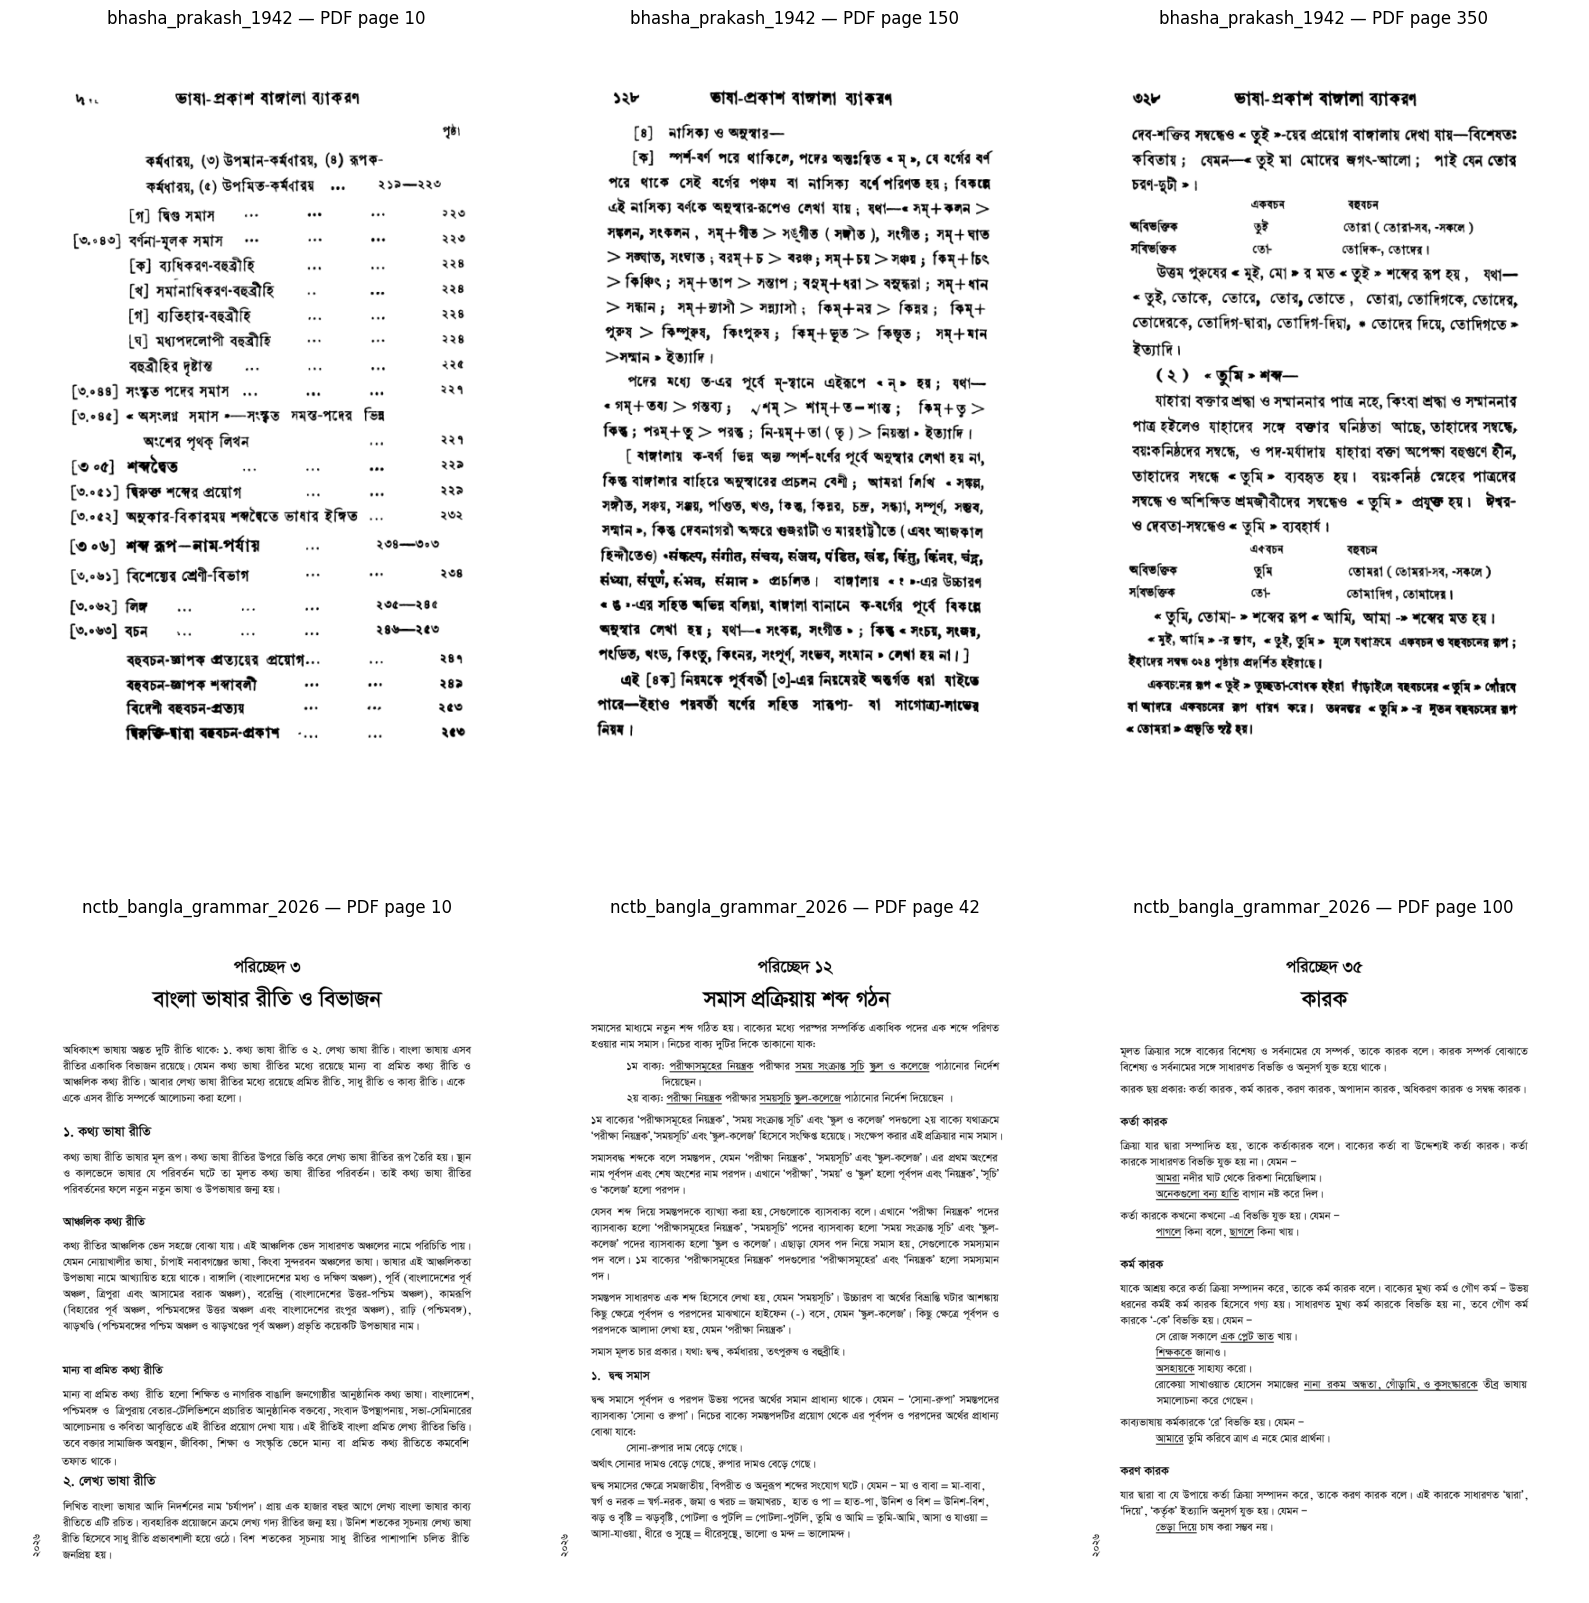

{'doc_id': 'bhasha_prakash_1942', 'pdf_page': 10, 'width_px_at_120dpi': 569, 'height_px_at_120dpi': 846, 'mean_gray': 242.69, 'gray_std': 46.88, 'dark_pixel_fraction_lt_128': 0.0482}
{'doc_id': 'bhasha_prakash_1942', 'pdf_page': 150, 'width_px_at_120dpi': 569, 'height_px_at_120dpi': 846, 'mean_gray': 232.09, 'gray_std': 62.95, 'dark_pixel_fraction_lt_128': 0.0898}
{'doc_id': 'bhasha_prakash_1942', 'pdf_page': 350, 'width_px_at_120dpi': 569, 'height_px_at_120dpi': 846, 'mean_gray': 236.11, 'gray_std': 57.02, 'dark_pixel_fraction_lt_128': 0.0747}
{'doc_id': 'nctb_bangla_grammar_2026', 'pdf_page': 10, 'width_px_at_120dpi': 870, 'height_px_at_120dpi': 1140, 'mean_gray': 241.95, 'gray_std': 44.98, 'dark_pixel_fraction_lt_128': 0.0532}
{'doc_id': 'nctb_bangla_grammar_2026', 'pdf_page': 42, 'width_px_at_120dpi': 870, 'height_px_at_120dpi': 1140, 'mean_gray': 241.77, 'gray_std': 45.02, 'dark_pixel_fraction_lt_128': 0.0533}
{'doc_id': 'nctb_bangla_grammar_2026', 'pdf_page': 100, 'width_px_at_12

In [11]:
from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

SAMPLE_PAGES = {
    "bhasha_prakash_1942": [10, 150, 350],
    "nctb_bangla_grammar_2026": [10, 42, 100],
}

figure, axes = plt.subplots(2, 3, figsize=(16, 18))
sample_scan_stats = []

for row_index, (doc_id, page_numbers) in enumerate(SAMPLE_PAGES.items()):
    with fitz.open(corpus_paths[doc_id]) as pdf:
        for column_index, pdf_page_number in enumerate(page_numbers):
            page = pdf.load_page(pdf_page_number - 1)
            pixmap = page.get_pixmap(dpi=120, colorspace=fitz.csGRAY, alpha=False)
            image = Image.open(BytesIO(pixmap.tobytes("png"))).convert("L")
            pixels = np.asarray(image, dtype=np.uint8)
            sample_scan_stats.append(
                {
                    "doc_id": doc_id,
                    "pdf_page": pdf_page_number,
                    "width_px_at_120dpi": image.width,
                    "height_px_at_120dpi": image.height,
                    "mean_gray": round(float(pixels.mean()), 2),
                    "gray_std": round(float(pixels.std()), 2),
                    "dark_pixel_fraction_lt_128": round(float((pixels < 128).mean()), 4),
                }
            )
            axis = axes[row_index, column_index]
            axis.imshow(image, cmap="gray")
            axis.set_title(f"{doc_id} — PDF page {pdf_page_number}")
            axis.axis("off")

plt.tight_layout()
plt.show()

for record in sample_scan_stats:
    print(record)
print("REAL PAGE SAMPLE EDA: PASS")


## 11. Declare the document-level split and corpus revision

In [12]:
split_by_document = {record["doc_id"]: record["split"] for record in corpus_records}
assert split_by_document == {
    "bhasha_prakash_1942": "train",
    "nctb_bangla_grammar_2026": "test",
}
assert len(split_by_document) == len(set(split_by_document))

print("Document-level split:", split_by_document)
print("Validation: one whole-chapter block will be selected from the 1942 train volume after layout inspection.")
print("Limitation: validation shares the train document's era, author, and typography.")
print("Corpus revision: A1 named the 2019 NCTB edition; A2 uses the selected 2026 218-page edition.")
print("The revision must be disclosed in A2 and confirmed with the instructor.")
print("DOCUMENT SPLIT DECLARATION: PASS")


Document-level split: {'bhasha_prakash_1942': 'train', 'nctb_bangla_grammar_2026': 'test'}
Validation: one whole-chapter block will be selected from the 1942 train volume after layout inspection.
Limitation: validation shares the train document's era, author, and typography.
Corpus revision: A1 named the 2019 NCTB edition; A2 uses the selected 2026 218-page edition.
The revision must be disclosed in A2 and confirmed with the instructor.
DOCUMENT SPLIT DECLARATION: PASS


## 12. Export the Phase 1 inventory and summary

In [13]:
phase1_inventory = {
    "status": "pass",
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "repository": REPO_URL,
    "branch": REPO_BRANCH,
    "commit": commit_hash,
    "documents": corpus_records,
    "total_pages": total_pages,
    "total_bytes": total_bytes,
    "total_size_mib": round(total_bytes / (1024 * 1024), 2),
    "word_count": None,
    "word_count_status": "pending measured OCR in Phase 6",
    "geometry": geometry_records,
    "sample_scan_statistics": sample_scan_stats,
    "split_by_document": split_by_document,
    "corpus_revision_from_a1": "2019 NCTB edition replaced by selected 2026 218-page edition",
}

inventory_path = ARTIFACT_DIR / "phase1_corpus_inventory.json"
inventory_path.write_text(
    json.dumps(phase1_inventory, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

summary_lines = [
    "# Phase 1 corpus summary",
    "",
    f"- Tested repository commit: `{commit_hash}`",
    f"- Documents: {len(corpus_records)}",
    f"- Raw pages: {total_pages}",
    f"- Source size: {total_bytes:,} bytes ({total_bytes / (1024**2):.2f} MiB)",
    "- Usable OCR words: pending Phase 6",
    "- Split: 1942 volume train; 2026 NCTB volume test; whole-chapter validation block pending",
    "- Corpus revision: A1's 2019 NCTB edition was replaced by the selected 2026 edition",
]
summary_path = ARTIFACT_DIR / "phase1_corpus_summary.md"
summary_path.write_text("\n".join(summary_lines) + "\n", encoding="utf-8")

print(inventory_path.read_text(encoding="utf-8"))
print("Exported:", inventory_path)
print("Exported:", summary_path)
print("PHASE 1 CORPUS INVENTORY: PASS")


{
  "status": "pass",
  "generated_at_utc": "2026-08-12T09:41:59.832851+00:00",
  "repository": "https://github.com/FAHIM-ISHTIAK/doc-agent-20.git",
  "branch": "fahim",
  "commit": "21c7880be4e68bb37b3b6fe29fccea9027301d98",
  "documents": [
    {
      "doc_id": "bhasha_prakash_1942",
      "filename": "bhasha_prakash_1942.pdf",
      "path": "/kaggle/input/datasets/fahimishtiak/bma-corpus/bhasha_prakash_1942.pdf",
      "year": 1942,
      "split": "train",
      "pages": 565,
      "bytes": 26715873,
      "size_mib": 25.48,
      "sha256": "2e6a6e08e942d91e0986e2282ddeec9e6b4882ac6f4b89e083bf9bab6e72d39b"
    },
    {
      "doc_id": "nctb_bangla_grammar_2026",
      "filename": "nctb_bangla_grammar.pdf",
      "path": "/kaggle/input/datasets/fahimishtiak/bma-corpus/nctb_bangla_grammar.pdf",
      "year": 2026,
      "split": "test",
      "pages": 218,
      "bytes": 143145319,
      "size_mib": 136.51,
      "sha256": "3cb900fb1ce51bb91e13e41d43c51d98260a29ffffbed5632b0adee13064

## Phase 1 result and remaining gate

Phase 1's reproducible corpus identity/EDA work is complete when all cells show PASS and a Kaggle version is saved with outputs. Download the executed notebook and the two files under `/kaggle/working/artifacts`.

Two values intentionally remain open:

1. the exact usable word count, which must come from measured OCR in Phase 6 rather than a PDF text layer;
2. the exact validation chapter block, which is selected after layout inspection while remaining entirely inside the 1942 train document.

The team must also disclose/confirm the change from A1's 2019 NCTB edition to the 2026 edition.

# Phase 2 — Reproducible Kaggle runtime

This phase proves that paths, small/full modes, package versions, random seeds, GPU details, and generated-artifact locations are explicit and repeatable. It does not run OCR or build the index yet.

## 13. Capture and check the complete runtime identity

In [14]:
import importlib.metadata as package_metadata
import shutil

TRACKED_DISTRIBUTIONS = [
    "torch",
    "numpy",
    "pydantic",
    "pydantic-settings",
    "PyYAML",
    "PyMuPDF",
    "Pillow",
    "pytest",
    "ruff",
    "black",
    "easyocr",
    "transformers",
    "accelerate",
    "qwen-vl-utils",
]

installed_versions = {}
for distribution in TRACKED_DISTRIBUTIONS:
    try:
        installed_versions[distribution] = package_metadata.version(distribution)
    except package_metadata.PackageNotFoundError:
        installed_versions[distribution] = None

gpu_records = []
if torch.cuda.is_available():
    for gpu_index in range(torch.cuda.device_count()):
        properties = torch.cuda.get_device_properties(gpu_index)
        gpu_records.append(
            {
                "index": gpu_index,
                "name": properties.name,
                "total_memory_gib": round(properties.total_memory / (1024**3), 2),
                "compute_capability": f"{properties.major}.{properties.minor}",
            }
        )

disk_usage = shutil.disk_usage("/kaggle/working")
runtime_identity = {
    "python": sys.version.replace("\n", " "),
    "platform": platform.platform(),
    "repository_commit": commit_hash,
    "torch": torch.__version__,
    "cuda_runtime": torch.version.cuda,
    "cuda_available": torch.cuda.is_available(),
    "gpus": gpu_records,
    "working_disk_free_gib": round(disk_usage.free / (1024**3), 2),
    "packages": installed_versions,
}

assert sys.version_info[:2] in {(3, 11), (3, 12)}
assert runtime_identity["cuda_available"], "Select a Kaggle GPU accelerator before running A2"
assert gpu_records, "At least one visible GPU is required for the selected Kaggle runtime"
assert all(installed_versions[name] is not None for name in TRACKED_DISTRIBUTIONS)

print(json.dumps(runtime_identity, ensure_ascii=False, indent=2))
print("RUNTIME IDENTITY: PASS")


{
  "python": "3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]",
  "platform": "Linux-6.12.90+-x86_64-with-glibc2.35",
  "repository_commit": "21c7880be4e68bb37b3b6fe29fccea9027301d98",
  "torch": "2.10.0+cu128",
  "cuda_runtime": "12.8",
  "cuda_available": true,
  "gpus": [
    {
      "index": 0,
      "name": "Tesla T4",
      "total_memory_gib": 14.56,
      "compute_capability": "7.5"
    },
    {
      "index": 1,
      "name": "Tesla T4",
      "total_memory_gib": 14.56,
      "compute_capability": "7.5"
    }
  ],
  "working_disk_free_gib": 19.49,
  "packages": {
    "torch": "2.10.0+cu128",
    "numpy": "2.0.2",
    "pydantic": "2.12.3",
    "pydantic-settings": "2.15.0",
    "PyYAML": "6.0.3",
    "PyMuPDF": "1.26.7",
    "Pillow": "11.3.0",
    "pytest": "8.4.2",
    "ruff": "0.16.2",
    "black": "26.5.1",
    "easyocr": "1.7.2",
    "transformers": "4.57.6",
    "accelerate": "1.14.0",
    "qwen-vl-utils": "0.0.14"
  }
}
RUNTIME IDENTITY: PASS


## 14. Validate portable paths and small/full modes

In [15]:
os.environ["DOC_AGENT_INPUT_ROOT"] = str(KAGGLE_INPUT)
os.environ["DOC_AGENT_DATA_DIR"] = str(REPO_DIR / "data" / "raw")
os.environ["DOC_AGENT_ARTIFACT_DIR"] = str(ARTIFACT_DIR)
os.environ["DOC_AGENT_RUN_MODE"] = "small"
os.environ["DOC_AGENT_SMALL_MAX_PAGES"] = "20"

from doc_agent.settings import Settings

small_runtime = Settings(_env_file=None)
small_runtime.ensure_writable_dirs()
assert small_runtime.input_root == KAGGLE_INPUT
assert small_runtime.data_dir == REPO_DIR / "data" / "raw"
assert small_runtime.artifact_dir == ARTIFACT_DIR
assert small_runtime.run_mode == "small"
assert small_runtime.page_limit == 20
assert small_runtime.data_dir.is_dir()
assert small_runtime.artifact_dir.is_dir()

os.environ["DOC_AGENT_RUN_MODE"] = "full"
full_runtime = Settings(_env_file=None)
assert full_runtime.run_mode == "full"
assert full_runtime.page_limit is None

# Continue notebook development in safe small mode.
os.environ["DOC_AGENT_RUN_MODE"] = "small"

print("Small mode page limit per document:", small_runtime.page_limit)
print("Full mode page limit per document:", full_runtime.page_limit)
print("Input root (read only):", small_runtime.input_root)
print("Generated data directory:", small_runtime.data_dir)
print("Artifact directory:", small_runtime.artifact_dir)
print("PORTABLE PATHS AND MODES: PASS")


Small mode page limit per document: 20
Full mode page limit per document: None
Input root (read only): /kaggle/input
Generated data directory: /kaggle/working/doc-agent-20/data/raw
Artifact directory: /kaggle/working/artifacts
PORTABLE PATHS AND MODES: PASS


## 15. Show exactly what small and full mode will process

In [16]:
mode_plan = []
for record in corpus_records:
    mode_plan.append(
        {
            "doc_id": record["doc_id"],
            "available_pages": record["pages"],
            "small_mode_pages": min(record["pages"], small_runtime.page_limit or record["pages"]),
            "full_mode_pages": record["pages"],
        }
    )

small_total = sum(record["small_mode_pages"] for record in mode_plan)
full_total = sum(record["full_mode_pages"] for record in mode_plan)
assert small_total == 40
assert full_total == 783

print(json.dumps(mode_plan, ensure_ascii=False, indent=2))
print(f"Small mode total: {small_total} pages")
print(f"Full mode total: {full_total} pages")
print("SMALL/FULL WORK PLAN: PASS")


[
  {
    "doc_id": "bhasha_prakash_1942",
    "available_pages": 565,
    "small_mode_pages": 20,
    "full_mode_pages": 565
  },
  {
    "doc_id": "nctb_bangla_grammar_2026",
    "available_pages": 218,
    "small_mode_pages": 20,
    "full_mode_pages": 218
  }
]
Small mode total: 40 pages
Full mode total: 783 pages
SMALL/FULL WORK PLAN: PASS


## 16. Prove deterministic random seeds

In [17]:
import random
import runpy

import numpy as np

seed_namespace = runpy.run_path(str(REPO_DIR / "scripts" / "set_seed.py"))
set_seed = seed_namespace["set_seed"]
seed_value = int(cfg["seed"])

first_seed_state = set_seed(seed_value)
first_values = {
    "python": [random.random() for _ in range(3)],
    "numpy": np.random.random(3).tolist(),
    "torch": torch.rand(3).cpu().tolist(),
}

second_seed_state = set_seed(seed_value)
second_values = {
    "python": [random.random() for _ in range(3)],
    "numpy": np.random.random(3).tolist(),
    "torch": torch.rand(3).cpu().tolist(),
}

assert first_values == second_values
assert first_seed_state == second_seed_state
assert first_seed_state["deterministic_algorithms"]

print("Seed state:", first_seed_state)
print("Repeated values:", first_values)
print("DETERMINISTIC SEED TEST: PASS")


Seed state: {'seed': 42, 'cuda_available': True, 'deterministic_algorithms': True}
Repeated values: {'python': [0.6394267984578837, 0.025010755222666936, 0.27502931836911926], 'numpy': [0.3745401188473625, 0.9507143064099162, 0.7319939418114051], 'torch': [0.8822692632675171, 0.9150039553642273, 0.38286375999450684]}
DETERMINISTIC SEED TEST: PASS


## 17. Run the Phase 2 configuration tests

In [18]:
test_result = run_command(
    [sys.executable, "-m", "pytest", "tests/test_data.py"],
    cwd=REPO_DIR,
)
assert test_result.returncode == 0
print("PHASE 2 CONFIGURATION TESTS: PASS")


$ /usr/bin/python3 -m pytest tests/test_data.py
...                                                                      [100%]
3 passed in 0.04s
PHASE 2 CONFIGURATION TESTS: PASS


## 18. Export the reproducibility snapshot

In [19]:
def sha256_path(path):
    return file_sha256(Path(path))


phase2_snapshot = {
    "status": "pass",
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "runtime": runtime_identity,
    "paths": {
        "input_root": str(small_runtime.input_root),
        "data_dir": str(small_runtime.data_dir),
        "artifact_dir": str(small_runtime.artifact_dir),
    },
    "modes": {
        "small_max_pages_per_document": small_runtime.page_limit,
        "small_total_pages": small_total,
        "full_total_pages": full_total,
    },
    "seed": first_seed_state,
    "file_hashes": {
        "pyproject.toml": sha256_path(REPO_DIR / "pyproject.toml"),
        "requirements.lock": sha256_path(REPO_DIR / "requirements.lock"),
        "configs/config.yaml": sha256_path(REPO_DIR / "configs" / "config.yaml"),
    },
}

phase2_path = ARTIFACT_DIR / "phase2_runtime_snapshot.json"
phase2_path.write_text(
    json.dumps(phase2_snapshot, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

snapshot_lines = [
    f"{name}=={version}"
    for name, version in sorted(installed_versions.items())
    if version is not None
]
requirements_snapshot_path = ARTIFACT_DIR / "phase2_requirements_snapshot.txt"
requirements_snapshot_path.write_text("\n".join(snapshot_lines) + "\n", encoding="utf-8")

print(phase2_path.read_text(encoding="utf-8"))
print("Exported:", phase2_path)
print("Exported:", requirements_snapshot_path)
print("PHASE 2 REPRODUCIBILITY SNAPSHOT: PASS")


{
  "status": "pass",
  "generated_at_utc": "2026-08-12T09:42:07.735678+00:00",
  "runtime": {
    "python": "3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]",
    "platform": "Linux-6.12.90+-x86_64-with-glibc2.35",
    "repository_commit": "21c7880be4e68bb37b3b6fe29fccea9027301d98",
    "torch": "2.10.0+cu128",
    "cuda_runtime": "12.8",
    "cuda_available": true,
    "gpus": [
      {
        "index": 0,
        "name": "Tesla T4",
        "total_memory_gib": 14.56,
        "compute_capability": "7.5"
      },
      {
        "index": 1,
        "name": "Tesla T4",
        "total_memory_gib": 14.56,
        "compute_capability": "7.5"
      }
    ],
    "working_disk_free_gib": 19.49,
    "packages": {
      "torch": "2.10.0+cu128",
      "numpy": "2.0.2",
      "pydantic": "2.12.3",
      "pydantic-settings": "2.15.0",
      "PyYAML": "6.0.3",
      "PyMuPDF": "1.26.7",
      "Pillow": "11.3.0",
      "pytest": "8.4.2",
      "ruff": "0.16.2",
      "black": "26.5.1",
      "ea

## Phase 2 result

Phase 2 is complete when Cells 13–18 all report PASS in a saved Kaggle version. The run must record the repository commit, Python/PyTorch/CUDA/GPU versions, installed bootstrap packages, portable paths, a 40-page small mode, a 783-page full mode, deterministic repeated random values, three passing configuration tests, and the exported runtime snapshot.

OCR/model-specific packages are deliberately not selected here; they are pinned later only after the Phase 6/7 experiments choose them.

# Phase 3 — Held-out pages and human ground truth

This phase prepares a balanced 12-page OCR evaluation slice. EasyOCR generates a typing draft, but that draft is not ground truth: a team member must correct every line against the page image, and a different member must independently review it.

## 19. Validate the representative held-out selection

In [20]:
labels_path = REPO_DIR / "grading_kit" / "labels.jsonl"
selection_records = [
    json.loads(line)
    for line in labels_path.read_text(encoding="utf-8").splitlines()
    if line.strip()
]

assert len(selection_records) == 12
selected_page_ids = [record["page_id"] for record in selection_records]
assert len(selected_page_ids) == len(set(selected_page_ids))

source_counts = Counter(record["doc_id"] for record in selection_records)
assert source_counts == {
    "bhasha_prakash_1942": 6,
    "nctb_bangla_grammar_2026": 6,
}
for record in selection_records:
    expected_id = f'{record["doc_id"]}_p{record["pdf_page"]:04d}'
    assert record["page_id"] == expected_id
    assert 1 <= record["pdf_page"] <= EXPECTED_CORPUS[record["doc_id"]]["expected_pages"]

covered_categories = {
    category
    for record in selection_records
    for category in record["categories"]
}
required_category_groups = {
    "clean text": {"clean_text"},
    "conjunct-heavy content": {"conjunct_heavy", "conjuncts"},
    "old letterpress": {"old_letterpress"},
    "numbered rules": {"numbered_rules", "numbered_rule_list"},
    "exercises": {"exercise"},
    "difficult scan": {"difficult_small_type", "scan_artifact"},
}
for group_name, alternatives in required_category_groups.items():
    assert covered_categories & alternatives, f"Missing category group: {group_name}"

print("Selected pages by source:", dict(source_counts))
print("Covered categories:", sorted(covered_categories))
print("HELD-OUT PAGE SELECTION: PASS")


Selected pages by source: {'bhasha_prakash_1942': 6, 'nctb_bangla_grammar_2026': 6}
Covered categories: ['clean_text', 'conjunct_heavy', 'conjuncts', 'difficult_small_type', 'distractors', 'examples', 'exercise', 'heading', 'morphology', 'numbered_list', 'numbered_rule_list', 'numbered_rules', 'old_letterpress', 'phonology', 'rule_list', 'scan_artifact', 'table', 'verb_inflection', 'word_classification', 'word_formation']
HELD-OUT PAGE SELECTION: PASS


## 20. Render the 300-DPI labeling bundle

In [21]:
from zipfile import ZIP_DEFLATED, ZipFile

PHASE3_DPI = 300
phase3_dir = ARTIFACT_DIR / "phase3_labeling_bundle"
phase3_pages_dir = phase3_dir / "heldout_pages"
phase3_pages_dir.mkdir(parents=True, exist_ok=True)

rendered_records = []
for record in selection_records:
    source_path = corpus_paths[record["doc_id"]]
    output_path = phase3_pages_dir / record["image_filename"]
    with fitz.open(source_path) as pdf:
        page = pdf.load_page(record["pdf_page"] - 1)
        pixmap = page.get_pixmap(dpi=PHASE3_DPI, colorspace=fitz.csGRAY, alpha=False)
        pixmap.save(str(output_path))

    rendered = dict(record)
    rendered["render_dpi"] = PHASE3_DPI
    rendered["image_sha256"] = file_sha256(output_path)
    rendered["image_bytes"] = output_path.stat().st_size
    rendered_records.append(rendered)

template_path = phase3_dir / "labels.template.jsonl"
template_path.write_text(
    "".join(json.dumps(record, ensure_ascii=False) + "\n" for record in rendered_records),
    encoding="utf-8",
)

selection_snapshot = {
    "status": "prepared_for_manual_transcription",
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "repository_commit": commit_hash,
    "render_dpi": PHASE3_DPI,
    "page_count": len(rendered_records),
    "source_counts": dict(source_counts),
    "records": rendered_records,
}
selection_snapshot_path = phase3_dir / "selection_snapshot.json"
selection_snapshot_path.write_text(
    json.dumps(selection_snapshot, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

instructions_path = phase3_dir / "LABELING_INSTRUCTIONS.md"
instructions_path.write_text(
    "# Human transcription instructions\n\n"
    "Use ocr_draft only as a typing aid. Compare every line with the PNG and place "
    "the corrected transcription in text; raw OCR is never ground truth.\n\n"
    "Use student IDs in transcriber and reviewer: 2105004, 2105001, or 2105006. "
    "A different member must review each record. Fill printed_page, transcriber, reviewer, "
    "text, and notes; set review_status to reviewed only after the second pass.\n",
    encoding="utf-8",
)

bundle_path = ARTIFACT_DIR / "phase3_labeling_bundle.zip"
with ZipFile(bundle_path, "w", compression=ZIP_DEFLATED) as archive:
    archive.write(template_path, template_path.name)
    archive.write(selection_snapshot_path, selection_snapshot_path.name)
    archive.write(instructions_path, instructions_path.name)
    for record in rendered_records:
        image_path = phase3_pages_dir / record["image_filename"]
        archive.write(image_path, f"heldout_pages/{image_path.name}")

assert bundle_path.is_file() and bundle_path.stat().st_size > 0
assert len(rendered_records) == 12
assert all((phase3_pages_dir / record["image_filename"]).is_file() for record in rendered_records)

print(f"Rendered {len(rendered_records)} pages at {PHASE3_DPI} DPI")
print("Labeling template:", template_path)
print("Download bundle:", bundle_path)
print("PHASE 3 PAGE RENDER: PASS")


Rendered 12 pages at 300 DPI
Labeling template: /kaggle/working/artifacts/phase3_labeling_bundle/labels.template.jsonl
Download bundle: /kaggle/working/artifacts/phase3_labeling_bundle.zip
PHASE 3 PAGE RENDER: PASS


## 21. Generate EasyOCR typing drafts (not ground truth)

In [22]:
import easyocr
import unicodedata


def reconstruct_easyocr_lines(results):
    items = []
    for bbox, text_value, confidence in results:
        x_min = min(point[0] for point in bbox)
        y_min = min(point[1] for point in bbox)
        y_max = max(point[1] for point in bbox)
        items.append(
            {
                "x": x_min,
                "y": (y_min + y_max) / 2,
                "height": max(y_max - y_min, 1),
                "text": text_value.strip(),
                "confidence": float(confidence),
            }
        )

    lines = []
    for item in sorted(items, key=lambda value: (value["y"], value["x"])):
        if not lines:
            lines.append({"y": item["y"], "height": item["height"], "items": [item]})
            continue
        current = lines[-1]
        tolerance = 0.65 * max(current["height"], item["height"])
        if abs(item["y"] - current["y"]) <= tolerance:
            current["items"].append(item)
            current["y"] = sum(value["y"] for value in current["items"]) / len(current["items"])
            current["height"] = max(current["height"], item["height"])
        else:
            lines.append({"y": item["y"], "height": item["height"], "items": [item]})

    text_lines = []
    for line in lines:
        ordered = sorted(line["items"], key=lambda value: value["x"])
        text_lines.append(" ".join(value["text"] for value in ordered if value["text"]))
    return "\n".join(line for line in text_lines if line), items


ocr_reader = easyocr.Reader(["bn", "en"], gpu=torch.cuda.is_available(), verbose=False)
drafts_dir = phase3_dir / "ocr_drafts"
drafts_dir.mkdir(parents=True, exist_ok=True)
for record in rendered_records:
    image_path = phase3_pages_dir / record["image_filename"]
    raw_results = ocr_reader.readtext(
        str(image_path), detail=1, paragraph=False, batch_size=8, workers=0
    )
    draft_text, detected_items = reconstruct_easyocr_lines(raw_results)
    record["ocr_draft_engine"] = "easyocr==1.7.2:bn+en"
    record["ocr_draft"] = unicodedata.normalize("NFC", draft_text)
    record["easyocr_draft"] = record["ocr_draft"]
    record["draft_selected_engine"] = "easyocr==1.7.2:bn+en"
    record["text"] = record["ocr_draft"]
    record["notes"] = "OCR-assisted draft; human correction pending"
    record["ocr_draft_mean_confidence"] = round(
        sum(item["confidence"] for item in detected_items) / max(len(detected_items), 1), 4
    )
    record["human_verified"] = False
    draft_path = drafts_dir / f'{record["page_id"]}.txt'
    draft_path.write_text(record["ocr_draft"] + "\n", encoding="utf-8")

assert all(record["ocr_draft"].strip() for record in rendered_records)
template_path.write_text(
    "".join(json.dumps(record, ensure_ascii=False) + "\n" for record in rendered_records),
    encoding="utf-8",
)
selection_snapshot["status"] = "ocr_drafts_ready_for_human_correction"
selection_snapshot["records"] = rendered_records
selection_snapshot_path.write_text(
    json.dumps(selection_snapshot, ensure_ascii=False, indent=2), encoding="utf-8"
)
instructions_path.write_text(
    "# Human correction instructions\n\n"
    "EasyOCR created ocr_draft only to avoid typing from zero. Compare every line with the PNG, "
    "correct the pre-filled text field, and set human_verified to true. Raw OCR is not a label.\n\n"
    "Use student IDs 2105004, 2105001, or 2105006. A different person must review "
    "the corrected text before review_status becomes reviewed.\n",
    encoding="utf-8",
)
with ZipFile(bundle_path, "w", compression=ZIP_DEFLATED) as archive:
    archive.write(template_path, template_path.name)
    archive.write(selection_snapshot_path, selection_snapshot_path.name)
    archive.write(instructions_path, instructions_path.name)
    for record in rendered_records:
        image_path = phase3_pages_dir / record["image_filename"]
        draft_path = drafts_dir / f'{record["page_id"]}.txt'
        archive.write(image_path, f"heldout_pages/{image_path.name}")
        archive.write(draft_path, f"ocr_drafts/{draft_path.name}")

print(f"Generated {len(rendered_records)} OCR drafts for human correction")
print("Download corrected labeling bundle:", bundle_path)
print("PHASE 3 OCR TYPING DRAFTS: PASS")


Generated 12 OCR drafts for human correction
Download corrected labeling bundle: /kaggle/working/artifacts/phase3_labeling_bundle.zip
PHASE 3 OCR TYPING DRAFTS: PASS


## 22. Generate final Qwen3-VL 8B drafts for historical pages

Only the six 1942 pages use the final 8B fallback. The clean NCTB pages retain EasyOCR. The JSONL keeps separate EasyOCR and Qwen3-VL 8B drafts; any pre-existing 4B draft is also preserved. Human correction against the PNG remains mandatory.

In [23]:
import gc
from html import escape as html_escape

from PIL import ImageFilter, ImageOps
from qwen_vl_utils import process_vision_info
from transformers import AutoModelForImageTextToText, AutoProcessor

QWEN_MODEL_ID = "Qwen/Qwen3-VL-8B-Instruct"
HISTORICAL_DOC_ID = "bhasha_prakash_1942"
QWEN_PROMPT = (
    "Transcribe every visible printed Bengali and English character on this historical "
    "grammar-book page exactly. Preserve headings, line order, Bengali digits, punctuation, "
    "examples, and tables row by row. Do not translate, modernize spelling, correct the book, "
    "explain, or invent missing text. Write [অস্পষ্ট] where the image is genuinely unreadable. "
    "Output only the transcription as plain text."
)

# Release EasyOCR's GPU allocation before loading the vision-language fallback.
del ocr_reader
gc.collect()
torch.cuda.empty_cache()

qwen_inputs_dir = phase3_dir / "qwen_inputs"
qwen_inputs_dir.mkdir(parents=True, exist_ok=True)
qwen_model = AutoModelForImageTextToText.from_pretrained(
    QWEN_MODEL_ID,
    dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True,
)
qwen_processor = AutoProcessor.from_pretrained(QWEN_MODEL_ID)

for record in rendered_records:
    previous_qwen_draft = record.get("qwen3_vl_draft", "").strip()
    record["qwen3_vl_4b_draft"] = record.get("qwen3_vl_4b_draft", previous_qwen_draft)
    record["qwen3_vl_8b_draft"] = ""
    record["qwen3_vl_draft"] = ""
    if record["doc_id"] != HISTORICAL_DOC_ID:
        continue

    image_path = phase3_pages_dir / record["image_filename"]
    qwen_input_path = qwen_inputs_dir / record["image_filename"]
    with Image.open(image_path) as source_image:
        enhanced = ImageOps.autocontrast(source_image.convert("L"), cutoff=1)
        enhanced = enhanced.filter(ImageFilter.UnsharpMask(radius=1.2, percent=125, threshold=3))
        enhanced.convert("RGB").save(qwen_input_path)

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": str(qwen_input_path)},
                {"type": "text", "text": QWEN_PROMPT},
            ],
        }
    ]
    prompt_text = qwen_processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs = process_vision_info(messages)
    model_inputs = qwen_processor(
        text=[prompt_text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    ).to(qwen_model.device)
    with torch.inference_mode():
        generated_ids = qwen_model.generate(
            **model_inputs, max_new_tokens=2048, do_sample=False, use_cache=True
        )
    trimmed_ids = generated_ids[:, model_inputs.input_ids.shape[1] :]
    qwen_text = qwen_processor.batch_decode(
        trimmed_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0].strip()
    qwen_text = unicodedata.normalize("NFC", qwen_text)
    record["qwen3_vl_8b_draft"] = qwen_text
    record["qwen3_vl_draft"] = qwen_text
    record["ocr_draft"] = qwen_text
    record["ocr_draft_engine"] = QWEN_MODEL_ID
    record["draft_selected_engine"] = QWEN_MODEL_ID
    record["text"] = qwen_text
    record["notes"] = "Qwen3-VL 8B OCR-assisted draft; human correction pending"
    record["human_verified"] = False
    (drafts_dir / f'{record["page_id"]}.qwen3-vl-8b.txt').write_text(
        qwen_text + "\n", encoding="utf-8"
    )

assert all(record["qwen3_vl_8b_draft"].strip() for record in rendered_records if record["doc_id"] == HISTORICAL_DOC_ID)
review_lines = [
    "# Final historical OCR model review",
    "",
    "The PNG is the authority. Compare the drafts below, then manually correct `text`.",
    "The selected final candidate is `Qwen/Qwen3-VL-8B-Instruct`.",
    "",
]
for record in rendered_records:
    if record["doc_id"] != HISTORICAL_DOC_ID:
        continue
    review_lines.extend(
        [
            f'## {record["page_id"]}',
            "",
            f'![{record["page_id"]}](heldout_pages/{record["image_filename"]})',
            "",
            "### EasyOCR baseline",
            f'<pre>{html_escape(record["easyocr_draft"])}</pre>',
        ]
    )
    if record["qwen3_vl_4b_draft"].strip():
        review_lines.extend(
            ["### Previous Qwen3-VL 4B draft", f'<pre>{html_escape(record["qwen3_vl_4b_draft"])}</pre>']
        )
    review_lines.extend(
        ["### Final Qwen3-VL 8B candidate", f'<pre>{html_escape(record["qwen3_vl_8b_draft"])}</pre>', ""]
    )
review_path = phase3_dir / "FINAL_MODEL_REVIEW.md"
review_path.write_text("\n".join(review_lines), encoding="utf-8")

template_path.write_text(
    "".join(json.dumps(record, ensure_ascii=False) + "\n" for record in rendered_records),
    encoding="utf-8",
)
selection_snapshot["records"] = rendered_records
selection_snapshot["historical_fallback"] = QWEN_MODEL_ID
selection_snapshot["final_model_hunt"] = {
    "status": "final_candidate_generated",
    "selected_model": QWEN_MODEL_ID,
    "baseline": "easyocr==1.7.2:bn+en",
    "human_image_check_required": True,
}
selection_snapshot_path.write_text(
    json.dumps(selection_snapshot, ensure_ascii=False, indent=2), encoding="utf-8"
)
with ZipFile(bundle_path, "w", compression=ZIP_DEFLATED) as archive:
    archive.write(template_path, template_path.name)
    archive.write(selection_snapshot_path, selection_snapshot_path.name)
    archive.write(instructions_path, instructions_path.name)
    archive.write(review_path, review_path.name)
    for record in rendered_records:
        image_path = phase3_pages_dir / record["image_filename"]
        easyocr_path = drafts_dir / f'{record["page_id"]}.txt'
        archive.write(image_path, f"heldout_pages/{image_path.name}")
        archive.write(easyocr_path, f"ocr_drafts/{easyocr_path.name}")
        qwen_path = drafts_dir / f'{record["page_id"]}.qwen3-vl-8b.txt'
        if qwen_path.is_file():
            archive.write(qwen_path, f"ocr_drafts/{qwen_path.name}")

del qwen_model, qwen_processor
gc.collect()
torch.cuda.empty_cache()
print("Final candidate:", QWEN_MODEL_ID)
print("Historical pages processed:", sum(record["doc_id"] == HISTORICAL_DOC_ID for record in rendered_records))
print("Human comparison report:", review_path)
print("Updated labeling bundle:", bundle_path)
print("HISTORICAL QWEN3-VL 8B FINAL OCR CANDIDATE: PASS")


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.90G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Final candidate: Qwen/Qwen3-VL-8B-Instruct
Historical pages processed: 6
Human comparison report: /kaggle/working/artifacts/phase3_labeling_bundle/FINAL_MODEL_REVIEW.md
Updated labeling bundle: /kaggle/working/artifacts/phase3_labeling_bundle.zip
HISTORICAL QWEN3-VL 8B FINAL OCR CANDIDATE: PASS


## 23. Visually verify every selected page

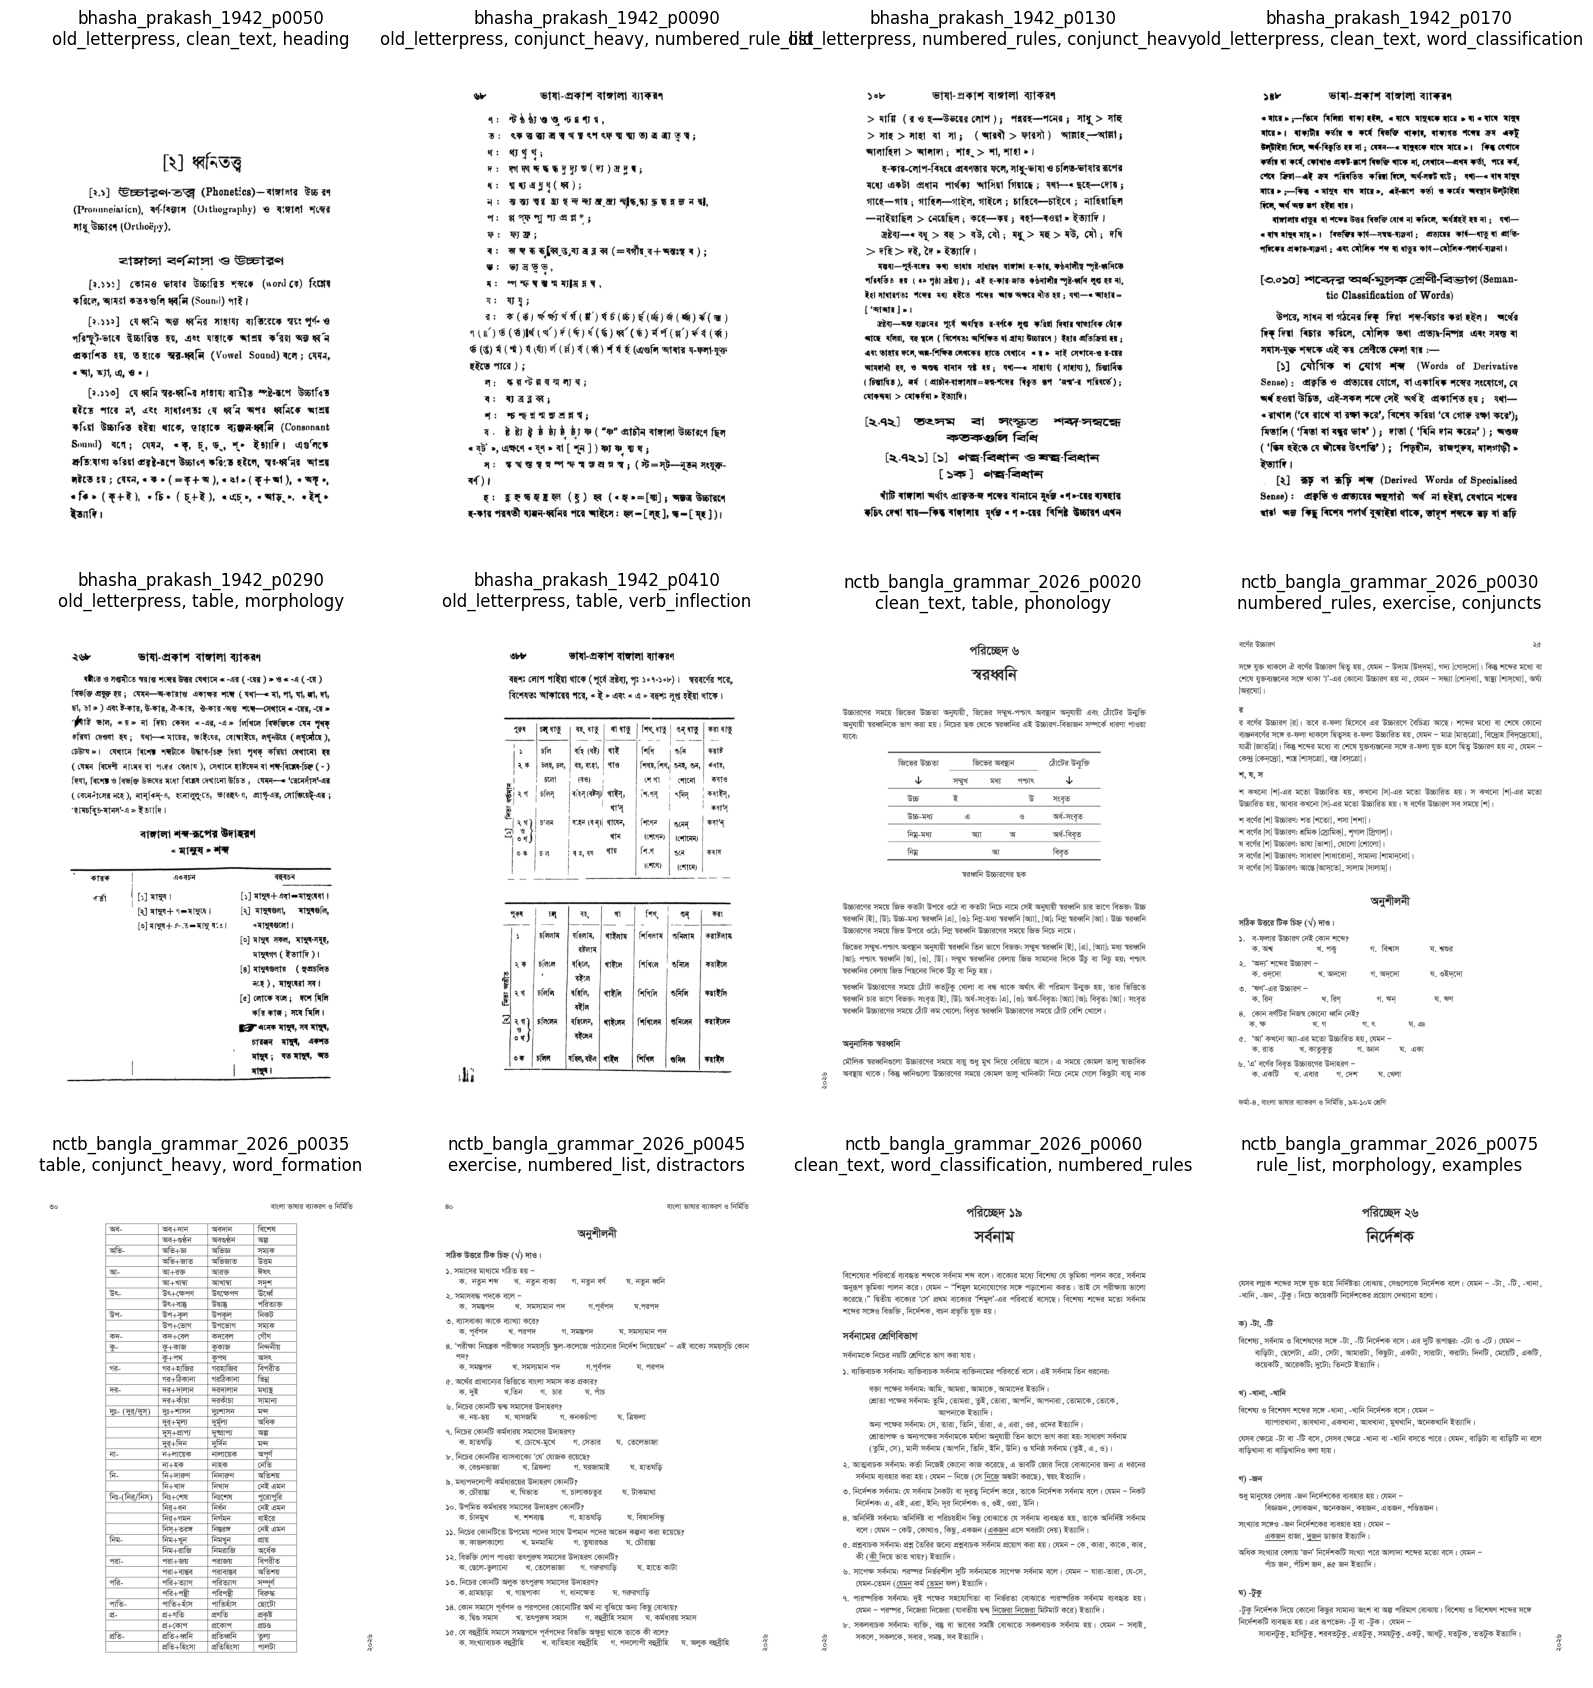

HELD-OUT PAGE GALLERY: PASS


In [24]:
figure, axes = plt.subplots(3, 4, figsize=(16, 17))
for axis, record in zip(axes.flat, rendered_records):
    image_path = phase3_pages_dir / record["image_filename"]
    with Image.open(image_path) as image:
        preview = image.copy()
    preview.thumbnail((700, 900))
    axis.imshow(preview, cmap="gray")
    axis.set_title(f'{record["page_id"]}\n{", ".join(record["categories"][:3])}')
    axis.axis("off")
plt.tight_layout()
plt.show()
print("HELD-OUT PAGE GALLERY: PASS")


## 24. Fail-closed human-correction and rights gate

In [25]:
import unicodedata

TEAM_MEMBER_IDS = {"2105004", "2105001", "2105006"}

required_label_fields = {
    "page_id",
    "doc_id",
    "pdf_page",
    "printed_page",
    "source_split",
    "image_filename",
    "image_sha256",
    "ocr_draft",
    "human_verified",
    "categories",
    "transcriber",
    "reviewer",
    "review_status",
    "text",
    "notes",
}
repo_pages_dir = REPO_DIR / "grading_kit" / "heldout_pages"
strict_errors = []

repo_labels = [
    json.loads(line)
    for line in labels_path.read_text(encoding="utf-8").splitlines()
    if line.strip()
]
repo_ids = [record.get("page_id") for record in repo_labels]
if set(repo_ids) != set(selected_page_ids) or len(repo_ids) != len(selected_page_ids):
    strict_errors.append("labels.jsonl must contain exactly the 12 selected page IDs")

for line_number, record in enumerate(repo_labels, start=1):
    missing_fields = required_label_fields - set(record)
    if missing_fields:
        strict_errors.append(f"line {line_number}: missing {sorted(missing_fields)}")
        continue
    page_id = record["page_id"]
    if not record["text"].strip():
        strict_errors.append(f"{page_id}: corrected human transcription is empty")
    elif unicodedata.normalize("NFC", record["text"]) != record["text"]:
        strict_errors.append(f"{page_id}: transcription is not Unicode NFC")
    if not str(record["printed_page"]).strip():
        strict_errors.append(f"{page_id}: printed_page is empty")
    if record["transcriber"].strip() not in TEAM_MEMBER_IDS:
        strict_errors.append(f"{page_id}: transcriber must be a valid team student ID")
    if record["reviewer"].strip() not in TEAM_MEMBER_IDS:
        strict_errors.append(f"{page_id}: reviewer must be a valid team student ID")
    elif record["reviewer"].strip() == record["transcriber"].strip():
        strict_errors.append(f"{page_id}: reviewer must differ from transcriber")
    if record["review_status"] != "reviewed":
        strict_errors.append(f"{page_id}: review_status must be reviewed")
    if record["human_verified"] is not True:
        strict_errors.append(f"{page_id}: OCR draft has not been human-verified")
    image_path = repo_pages_dir / record["image_filename"]
    if not image_path.is_file():
        strict_errors.append(f"{page_id}: permitted committed image is missing")
    elif file_sha256(image_path) != record["image_sha256"]:
        strict_errors.append(f"{page_id}: image SHA-256 mismatch")

if strict_errors:
    print(f"PHASE 3 MANUAL GATE: PENDING ({len(strict_errors)} issue(s))")
    for error in strict_errors[:20]:
        print("-", error)
    if len(strict_errors) > 20:
        print(f"- ... and {len(strict_errors) - 20} more")
    print("Correct the OCR drafts, complete independent review, and resolve the rights gate.")
else:
    print(f"Validated {len(repo_labels)} manually transcribed and independently reviewed pages")
    print("PHASE 3 HELD-OUT LABELS: PASS")


Validated 12 manually transcribed and independently reviewed pages
PHASE 3 HELD-OUT LABELS: PASS


## Phase 3 result

The automated preparation is complete when page selection, rendering, OCR typing drafts, and the gallery report PASS. Phase 3 itself is complete only after the final strict cell reports `PHASE 3 HELD-OUT LABELS: PASS`. A `PENDING` result is expected until humans correct the drafts, independently review them, and resolve permission to share the selected page samples.